In [1]:
import xgi 
from matplotlib import pyplot as plt 
import seaborn as sns
import numpy as np
import os 
import pandas as pd
import pickle
import matplotlib.colors as mcolors
from itertools import product
from scipy.special import binom
from multiprocessing import Pool
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import importlib 
import time
from sod import *
from collections import Counter, defaultdict
from multiprocessing import Pool
from scipy.interpolate import make_interp_spline, BSpline
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem", "src") 
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")

plt.style.use('seaborn-v0_8-whitegrid')

def expectation(x):
    
    to_sum = [(i)*j for i,j in enumerate(x)]
      
    return sum(to_sum)
realworld_Hgraphs = ["coauth-dblp", "coauth-mag-geology", "coauth-mag-history",
                     "diseasome", "kaggle-whats-cooking", "ndc-classes", "ndc-substances",
                     "tags-ask-ubuntu", "tags-math-sx" , "tags-stack-overflow", "threads-ask-ubuntu", 
                     "threads-math-sx", "threads-stack-overflow",
                     "congress-bills", "contact-high-school", "contact-primary-school",
                     "email-enron", "email-eu", "hospital-lyon", "hypertext-conference", 
                     "invs13", "invs15",  "malawi-village", "science-gallery", "sfhh-conference"]

C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\utils\utilities.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [7]:

# p_gamma = -np.sort(-np.random.exponential(scale=1.0, size=10))
# p_gamma = list(p_gamma / p_gamma.sum())

# print(p_gamma)
# expectation(p_gamma)

eta_list = [0.3, 0.7]
beta_list = []

gamma_list = []


p_beta_1 = [0.90502832570338695,
 0.06852597102421798,
 0.00695958124156278,
 0.00425430441260074,
 0.00513923414596366,
 0.00283459294063147,
 0.00219491091589968,
 0.00355751868523734,
 0.000874040537457661,
 0.0006315203930418162]

p_beta_2 = [0.1181696191800098,
 0.56904908541005407,
 0.28176865827877373,
 0.00922959431020997,
 0.0054277044922998,
 0.00429578036753658,
 0.003301470269982085,
 0.003939276201320242,
 0.00377219213273467,
 0.001046619357079092]


beta_list = [p_beta_1, p_beta_2]

#p_gamma = -np.sort(-np.random.exponential(scale=1.0, size=20))
#p_gamma = list(p_gamma / p_gamma.sum())
p_gamma_1 = [0.26808510691453546,
0.14626545184476625,
 0.10855257597549402,
 0.09914093069058083,
 0.07015466087950174,
 0.05779366818337918,
 0.040675224620690405,
 0.040422307282760035,
 0.03890813877620562,
 0.03606039013263103,
 0.026425470730908805,
 0.02167258582451556,
 0.015359102952971269,
 0.009505581418620465,
 0.0074926102365517385,
 0.00499058812177074,
 0.004907000319279024,
 0.0023934645186247435,
 0.0010124215022168882,
 0.00018271907399612376]

p_gamma_2 = [0.82894182078922285,
 0.06215493012449843,
 0.01192666284335375,
 0.00279141892191949,
 0.00847290102333172,
 0.00886377827593374,
 0.00625207194824165,
 0.00984957246975516,
 0.00301749402598405,
 0.000088960379657,
 0.00366484857364415,
 0.002608868022124676,
 0.009726750682067864,
 0.007883420960180417,
 0.008534809253028417,
 0.008444923410680536,
 0.007057473316011906,
 0.004988774770066662,
 0.003532987383654084,
 0.0011975328266434495]

gamma_list = [p_gamma_1, p_gamma_2]

In [8]:
def process_intersect(Rmat):
    rk = []
    for r in Rmat:
        
        #print(r)

        i_size = max([x[0] for x in r.keys()])
        j_size = max([x[1] for x in r.keys()])
        k_size = max([x[2] for x in r.keys()])


        #print(i_size, j_size, k_size) 

        r_ijk = np.zeros(shape=(i_size+1, j_size+1, k_size+1))

        for key in r.keys():
            r_ijk[key] = r[key]

        # Transpose the array to bring the first two axes to the end
        array_transposed = np.transpose(r_ijk, (2, 0, 1))
        # Apply np.triu along the last two axes
        upper_triangle_transposed = np.triu(array_transposed)
        # Transpose the result back to the original shape
        upper_triangle = np.transpose(upper_triangle_transposed, (1, 2, 0))


        normalized_rijk = upper_triangle/np.sum(upper_triangle)

        rk.append(np.sum(normalized_rijk, axis = (0,1)))
        
    return rk

In [4]:
save_name = "email-enron"

with open('fig_backup/res_{}.pkl'.format(save_name), 'rb') as fp:
    pars = pickle.load(fp)
    ll = process_intersect(pars["INTERSECTION"])

    
for item in ll:
    
    print(expectation(item))
    
    
timeline = [x*100 for x in range(1, 101)]
len(ll)



                  
# print(rk[0]) 

1.0
0.9250746268656715
0.8697895902547064
0.8638154613466338
0.8442874251497003
0.8226012201885745
0.8169920521703689
0.8005087390761546
0.7956048834628193
0.7910909090909093
0.7897134836099414
0.7771551484873712
0.780884526695441
0.7770102987661877
0.7755229846768816
0.7755707370393506
0.7724203755576304
0.7673089024615954
0.7599258008250509
0.7557471264367818
0.7516293828335712
0.7480149518813763
0.7451539028399755
0.7389868804664722
0.7332215913634547
0.7292020820394526
0.726751957436889
0.7218717804865605
0.7183249533454571
0.7154666222370318
0.7122576484172642
0.7078096688534832
0.7051273718707831
0.7026322707854089
0.7003590810788751
0.6996300410379827
0.6978470391493897
0.6947421038784809
0.6949388388250215
0.6923575356160956
0.689904544400235
0.6883140068691133
0.6850258728364961
0.6848190493896011
0.6825234886074689
0.679422242801659
0.6769114765079399
0.6759853849892384
0.6740757612981942
0.6728265546890618
0.6712862914230578
0.6707012704657382
0.6676313831850871
0.6664265876

108

Assortativity_Top2
100
100
100
100
Clustering Coefficient
100
100
100
100
Edit Simpliciality
100
100
100
100
Intersection Sizes
100
100
100
100


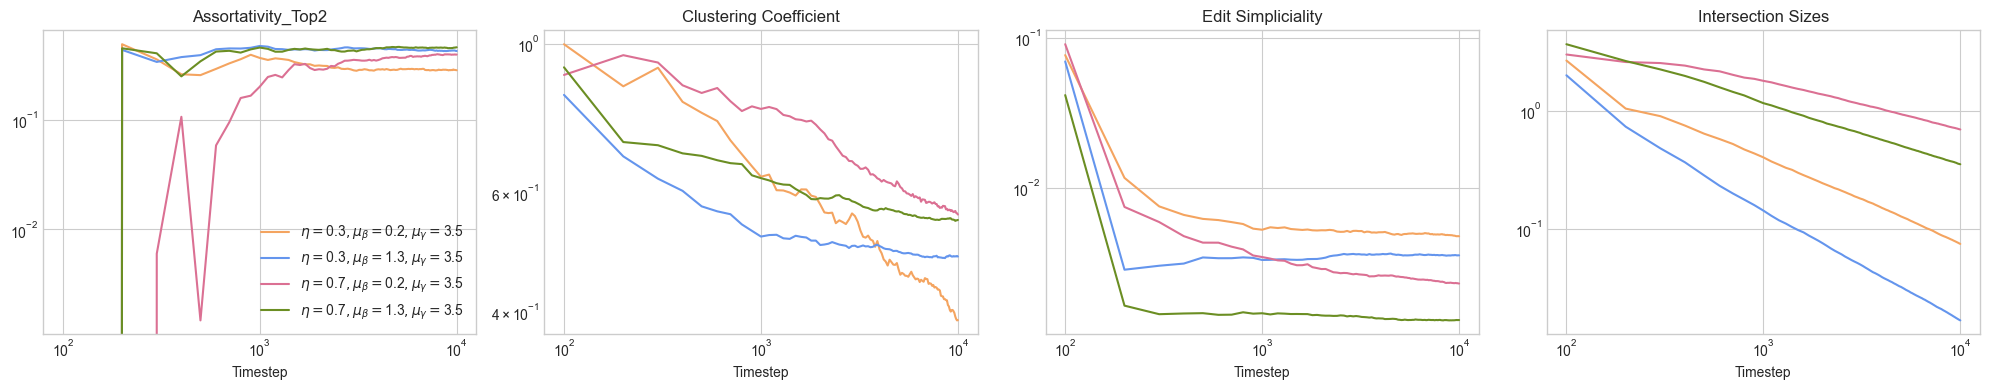

In [35]:
# properties = ["Assortativity", "Assortativity_TopBottom", "Assortativity_Top2", 
#               "Clustering Coefficient", "Edit Simpliciality", "Face Edit Simpliciality"]
# idx = ["assort", "assort_tb", "assort_t2", "cluster", "SF", "FES"]
# idx_er = ["assort_er", "assort_tb_er", "assort_t2_er", "cluster_er", "SF_er", "FES_er"]
#"Face Edit Simpliciality","FES",

properties = [ "Assortativity_Top2", "Clustering Coefficient", "Edit Simpliciality",  "Intersection Sizes"]
idx = ["assort_t2", "cluster", "SF",  "INTERSECTION"]




fig, ax = plt.subplots(1, 4, figsize = (20, 4), sharey= False)
ax = ax.flatten()
inferno = ["sandybrown", "cornflowerblue", "palevioletred", "olivedrab",
          "sandybrown", "cornflowerblue", "palevioletred", "olivedrab"]                                   
                                        
timeline = [x*100 for x in range(1, 101)]


for i in range(4):
    property_ = properties[i]
    print(property_)
    ax[i].loglog()
    ax[i].set(title = f"{property_}")
    ax[i].set(xlabel = "Timestep")
    
    count = 0
    for eta in eta_list:
        for beta in beta_list:
            for gamma in gamma_list[0:1]:

                save_name = "eta_" + str(eta) + "_beta_" + str(round(expectation(beta),2)) + "_gamma_" + str(round(expectation(gamma),2)) 
                #print(save_name)
                
                lab = r"$\eta = $" + str(eta) + r"$, \mu_{\beta} = $" + str(round(expectation(beta), 1)) + r"$, \mu_{\gamma} = $" + str(round(expectation(gamma),1)) 
               
                with open('fig_backup/res_{}.pkl'.format(save_name), 'rb') as fp:
                    pars = pickle.load(fp)
                
                ll = process_intersect(pars["INTERSECTION"])
                
                mean_inter = [expectation(x) for x in ll]
                print(len(ll))
                
                if i in range(3):
                    
                    ax[i].plot(timeline, pars[idx[i]], label = lab, color = inferno[count])
                elif i == 3:
                    ax[i].plot(timeline, mean_inter, label = lab, color = inferno[count])
                count = count + 1

ax[0].legend() #bbox_to_anchor=(-0.1, 0.7)
#ax[0].set(ylabel = "Edge intersection rate (normalized)")
plt.tight_layout()
plt.savefig("figures/backup_fig1.pdf",bbox_inches='tight')

Assortativity_Top2
Clustering Coefficient
Edit Simpliciality
Intersection Sizes


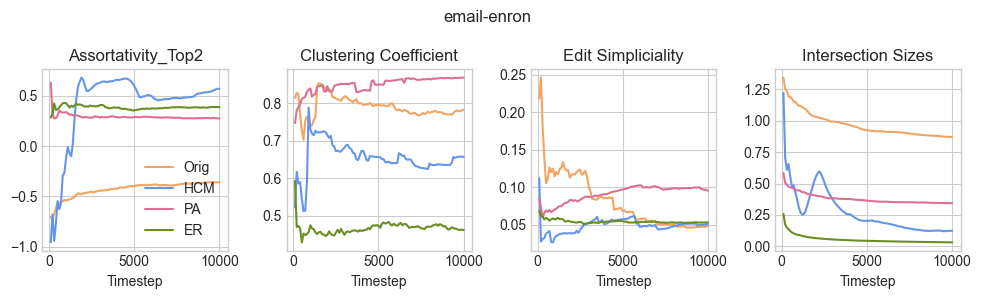

In [10]:
properties = [ "Assortativity_Top2", "Clustering Coefficient", "Edit Simpliciality",  "Intersection Sizes"]
idx = ["assort_t2", "cluster", "SF",  "INTERSECTION"]
fig, ax = plt.subplots(1, 4, figsize = (10, 3), sharey= False)
ax = ax.flatten()
inferno = ["sandybrown", "cornflowerblue", "palevioletred", "olivedrab",
          "sandybrown", "cornflowerblue", "palevioletred", "olivedrab"]                                   
                                        
timeline = [x*100 for x in range(1, 101)]

suffix = ["", "_OG", "_PA", "_ER"]
labb = ["HCM", "Orig", "PA", "ER"]

# data_name = "invs15"
data_name = "email-enron"
# data_name = "ndc-substances"
for i in range(4):
    property_ = properties[i]
    print(property_)
    #ax[i].loglog()
    ax[i].set(title = f"{property_}")
    ax[i].set(xlabel = "Timestep")
    
    count = 0
    
    for jj, ss in enumerate(suffix):
    
        with open('fig_backup/res_{}{}.pkl'.format(data_name, ss), 'rb') as fp:
            pars = pickle.load(fp)

        ll = process_intersect(pars["INTERSECTION"])
        mean_inter = [expectation(x) for x in ll]

        if i in range(3):
            ax[i].plot(timeline, pars[idx[i]][0:100], label = labb[jj], color = inferno[jj])
        elif i == 3:
            ax[i].plot(timeline, mean_inter[0:100], label = labb[jj], color = inferno[jj])
            
    

            
            
fig.suptitle(data_name) 
ax[0].legend() #bbox_to_anchor=(-0.1, 0.7)
#ax[0].set(ylabel = "Edge intersection rate (normalized)")
plt.tight_layout()
plt.savefig("figures/backup_email_enron_new.pdf",bbox_inches='tight')

In [25]:
data_name = "email-enron"
ss = ""
with open('fig_backup/res_{}{}.pkl'.format(data_name, ss), 'rb') as fp:
    pars = pickle.load(fp)
    
pars["assort_t2"]

[-0.032190686551872495,
 -0.0956359829421579,
 -0.24273492159014545,
 -0.20755289690920334,
 -0.25497495426531896,
 -0.23121813647197828,
 -0.19955788062652616,
 -0.19824841961711034,
 -0.22569658270656967,
 -0.23422617227151288,
 -0.24295794723212674,
 -0.24033951100976766,
 -0.21720372387760378,
 -0.19397505033900034,
 -0.18496412797984865,
 -0.18293349396741068,
 -0.19126868478457096,
 -0.1905994368307567,
 -0.19841175126817778,
 -0.1844465072739517,
 -0.18209407027897107,
 -0.17395937426668848,
 -0.17761978823001237,
 -0.18538667483668872,
 -0.18663433385008307,
 -0.17445147987123744,
 -0.16878419417147314,
 -0.17080552790676362,
 -0.16756613362696327,
 -0.1721108006964235,
 -0.17129635562160067,
 -0.17958202167241497,
 -0.17903090078721018,
 -0.18199468581396405,
 -0.18722826892488664,
 -0.1995164822466313,
 -0.1965800015818227,
 -0.19284292987379115,
 -0.1945709522109806,
 -0.19538601240288825,
 -0.19962437904220554,
 -0.20513459427110675,
 -0.20337685493599186,
 -0.2112135042862